# COM00180M ROCS-M Individual Open Assessment — Reproducible Analysis Notebook

This notebook contains all computations, tables and figures used to answer:

• Question 1 — Renewable electricity by income group (2010–2022)  
• Question 2 — CO₂ emissions per capita in Europe & Central Asia (2010–2022)

Run using: Kernel → Restart & Run All

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr

np.random.seed(42)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [6]:
DATA_FILE = "../wdi_climate_development_2010_2022.csv"

candidate_paths = [
    Path.cwd() / DATA_FILE,
    Path.cwd() / "data" / DATA_FILE,
    Path("/mnt/data") / DATA_FILE
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(f"Could not find {DATA_FILE}. Place it next to this notebook or in ./data/")

df = pd.read_csv(data_path)

print("Loaded:", data_path)
print("Shape:", df.shape)

df.head()

Loaded: /Users/palz/Desktop/ROCS final/renewable-energy-co2-analysis/../wdi_climate_development_2010_2022.csv
Shape: (2782, 20)


,Country_Code,Country_Name,Region,Income_Level,Year,CO2_Emissions_Per_Capita,CO2_Emissions_Total_MT,Forest_Area_Percent,Freshwater_Resources_Per_Capita,PM25_Air_Pollution,Energy_Use_Per_Capita,Renewable_Electricity_Percent,Electric_Power_Consumption_Per_Capita,GDP_Per_Capita,GDP_Growth_Annual_Percent,Industry_Value_Added_Percent_GDP,Trade_Percent_GDP,Population_Total,Urban_Population_Percent,Population_Growth_Annual_Percent
0,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2010,0.275381,7.7889,1.852782,54.757019,49.679377,NaN,81.752865,NaN,560.621505,14.362441,21.151421,NaN,28284089.0,23.737,2.934687
1,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2011,0.388742,11.4087,1.852782,54.757019,61.817056,NaN,74.400759,NaN,606.694676,0.426355,22.740252,NaN,29347708.0,23.948,3.691503
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2012,0.319627,9.7678,1.852782,54.757019,70.922317,NaN,79.797959,NaN,651.417134,12.752287,21.157807,NaN,30560034.0,24.160,4.047863
3,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2013,0.262470,8.3000,1.852782,54.757019,73.131816,NaN,81.008636,NaN,637.087099,5.600745,20.444605,NaN,31622704.0,24.373,3.418227
4,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2014,0.238643,7.8257,1.852782,54.757019,77.143728,NaN,85.461475,NaN,625.054942,2.724543,21.229663,NaN,32792523.0,24.587,3.632519


In [7]:
required_cols = [
    "Country_Code","Country_Name","Income_Level","Region","Year",
    "Renewable_Electricity_Percent","CO2_Emissions_Per_Capita"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError("Missing required columns: " + ", ".join(missing))

print("Year range:", df["Year"].min(), "to", df["Year"].max())


Year range: 2010 to 2022


# Q1 Renewable electricity (% of total output), 2010–2022

In [8]:
q1_raw = df[
    ["Country_Code","Country_Name","Income_Level","Year","Renewable_Electricity_Percent"]
].copy()

q1_raw = q1_raw[q1_raw["Income_Level"].isin(["High income", "Low income"])].copy()

q1_raw["Renewable_Electricity_Percent"] = pd.to_numeric(
    q1_raw["Renewable_Electricity_Percent"], errors="coerce"
)

q1_raw.head()

,Country_Code,Country_Name,Income_Level,Year,Renewable_Electricity_Percent
0,AFG,Afghanistan,Low income,2010,81.752865
1,AFG,Afghanistan,Low income,2011,74.400759
2,AFG,Afghanistan,Low income,2012,79.797959
3,AFG,Afghanistan,Low income,2013,81.008636
4,AFG,Afghanistan,Low income,2014,85.461475


## Q1(i)(a) Data preparation and aggregation

Countries are treated as independent units.  
Each country is represented by its mean renewable electricity share over available years (2010–2022).  
Countries with fewer than three observed years are excluded to reduce instability from sparse data.

In [9]:
coverage = (
    q1_raw.groupby(["Country_Code","Country_Name","Income_Level"])["Renewable_Electricity_Percent"]
          .apply(lambda s: s.notna().sum())
          .reset_index(name="n_years_available")
)

MIN_YEARS = 3
keep_codes = coverage.loc[coverage["n_years_available"] >= MIN_YEARS, "Country_Code"]

q1_kept = q1_raw[q1_raw["Country_Code"].isin(keep_codes)].copy()

q1_country = (
    q1_kept.groupby(["Country_Code","Country_Name","Income_Level"])["Renewable_Electricity_Percent"]
          .agg(mean_renew="mean", median_renew="median", n_years="count")
          .reset_index()
)

q1_country.head()

,Country_Code,Country_Name,Income_Level,mean_renew,median_renew,n_years
0,ABW,Aruba,High income,15.057401,14.798585,12
1,AFG,Afghanistan,Low income,83.374700,84.066735,12
2,AND,Andorra,High income,98.238352,99.548555,12
3,ARE,United Arab Emirates,High income,1.080674,0.255859,12
4,ASM,American Samoa,High income,2.403042,1.689781,12


## Q1(i)(b) Data quality issues

Missingness is assessed by income group and country coverage.  
Potential outliers are screened using an IQR rule on country-level means.

In [10]:
q1_raw.groupby("Income_Level")["Renewable_Electricity_Percent"].apply(lambda s: s.isna().mean())

Income_Level
High income    0.160256
Low income     0.104615
Name: Renewable_Electricity_Percent, dtype: float64

In [11]:
coverage.groupby("Income_Level")["n_years_available"].describe()

,count,mean,std,min,25%,50%,75%,max
Income_Level,,,,,,,,
High income,84.0,10.916667,3.362473,0.0,12.0,12.0,12.0,12.0
Low income,25.0,11.640000,0.860233,9.0,12.0,12.0,12.0,12.0


In [12]:
def iqr_bounds(series):
    x = series.dropna().values
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for grp in ["High income","Low income"]:
    vals = q1_country.loc[q1_country["Income_Level"] == grp, "mean_renew"]
    lo, hi = iqr_bounds(vals)
    print(grp, "IQR bounds:", lo, hi)
    print("Outliers:", vals[(vals < lo) | (vals > hi)].shape[0])

High income IQR bounds: -58.72231957177266 104.03668987745297
Outliers: 0
Low income IQR bounds: -112.42673098636311 200.8555579594149
Outliers: 0


## Q1(ii)(a) Visualisation

## Distribution of renewable electricity by income group

/var/folders/wr/6gjrm5p91_l1j7cdbny12j4h0000gn/T/ipykernel_6480/2752343769.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([high, low], labels=["High income", "Low income"], showmeans=True)


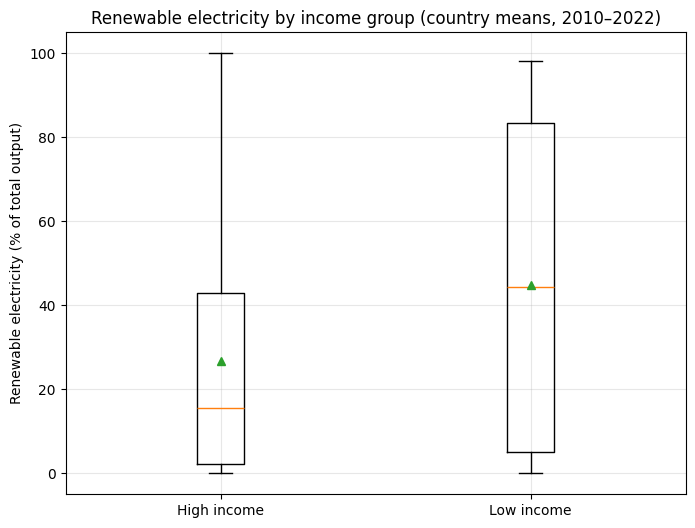

In [13]:
high = q1_country.loc[q1_country["Income_Level"] == "High income", "mean_renew"].dropna()
low  = q1_country.loc[q1_country["Income_Level"] == "Low income",  "mean_renew"].dropna()

plt.figure(figsize=(8,6))
plt.boxplot([high, low], labels=["High income", "Low income"], showmeans=True)
plt.ylabel("Renewable electricity (% of total output)")
plt.title("Renewable electricity by income group (country means, 2010–2022)")
plt.grid(alpha=0.3)
plt.show()

## Q1(ii)(b) Descriptive statistics

In [14]:
def desc(x):
    x = x.dropna()
    return pd.Series({
        "n_countries": int(x.shape[0]),
        "mean": float(x.mean()),
        "median": float(x.median()),
        "std": float(x.std(ddof=1)) if x.shape[0] > 1 else np.nan,
        "IQR": float(x.quantile(0.75) - x.quantile(0.25)),
        "min": float(x.min()),
        "max": float(x.max()),
    })

q1_desc = pd.concat([desc(high).rename("High income"),
                     desc(low).rename("Low income")], axis=1)

q1_desc

,High income,Low income
n_countries,77.000000,25.000000
mean,26.621820,44.751754
median,15.580950,44.367835
std,29.348587,37.231755
IQR,40.689752,78.320572
min,0.000000,0.143869
max,99.986228,98.071101


## Q1(iii)(a–d) Inferential comparison

A Mann–Whitney U test is used due to bounded percentage data (0–100), potential skew/outliers,
and to avoid normality assumptions.

In [15]:
u_stat, p_val = stats.mannwhitneyu(high, low, alternative="two-sided")
n1, n2 = len(high), len(low)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

pd.DataFrame({
    "U": [u_stat],
    "p_value": [p_val],
    "n_high": [n1], 
    "n_low": [n2],
    "rank_biserial": [rank_biserial],
    "mean_difference (high_minus_low)": [high.mean() - low.mean()],
})

,U,p_value,n_high,n_low,rank_biserial,mean_difference (high_minus_low)
0,676.0,0.026084,77,25,0.297662,-18.129935


# Question 2 — CO₂ emissions per capita (Europe & Central Asia), 2010–2022

In [16]:
q2_raw = df[df["Region"] == "Europe & Central Asia"][
    ["Country_Code","Country_Name","Year","CO2_Emissions_Per_Capita"]
].copy()

q2_raw["CO2_Emissions_Per_Capita"] = pd.to_numeric(q2_raw["CO2_Emissions_Per_Capita"], errors="coerce")

q2_raw.head()

,Country_Code,Country_Name,Year,CO2_Emissions_Per_Capita
13,ALB,Albania,2010,1.564321
14,ALB,Albania,2011,1.716993
15,ALB,Albania,2012,1.562853
16,ALB,Albania,2013,1.647374
17,ALB,Albania,2014,1.763799


## Q2(i)(a) Data preparation

In [17]:
q2_raw = df[df["Region"] == "Europe & Central Asia"][
    ["Country_Code", "Country_Name", "Year", "CO2_Emissions_Per_Capita"]
].copy()


q2_raw["CO2_Emissions_Per_Capita"] = pd.to_numeric(
    q2_raw["CO2_Emissions_Per_Capita"], errors="coerce"
)


print("Rows:", q2_raw.shape[0])
print("Countries:", q2_raw["Country_Name"].nunique())
display(q2_raw.head())

Rows: 728
Countries: 56


,Country_Code,Country_Name,Year,CO2_Emissions_Per_Capita
13,ALB,Albania,2010,1.564321
14,ALB,Albania,2011,1.716993
15,ALB,Albania,2012,1.562853
16,ALB,Albania,2013,1.647374
17,ALB,Albania,2014,1.763799


## Q2(i)(b) Data quality issues

In [18]:
region_df = df[df["Region"] == "Europe & Central Asia"].copy()

q2_df = region_df[["Country_Name", "Year", "CO2_Emissions_Per_Capita"]].copy()

print("Rows in region subset:", q2_df.shape[0])
print("Countries in region:", q2_df["Country_Name"].nunique())

missing_by_country_q2 = (
    q2_df.groupby("Country_Name")["CO2_Emissions_Per_Capita"]
    .apply(lambda x: x.isnull().sum())
    .reset_index(name="Missing_Years")
)

valid_by_country_q2 = (
    q2_df.groupby("Country_Name")["CO2_Emissions_Per_Capita"]
    .apply(lambda x: x.notnull().sum())
    .reset_index(name="Valid_Years")
)

q2_missing_summary = missing_by_country_q2.merge(valid_by_country_q2, on="Country_Name")
display(q2_missing_summary.head(20))

print("\nDistribution of missing years (CO2_Emissions_Per_Capita):")
print(q2_missing_summary["Missing_Years"].value_counts().sort_index())

print("\nCO2_Emissions_Per_Capita summary (region rows):")
display(q2_df["CO2_Emissions_Per_Capita"].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]))

Rows in region subset: 728
Countries in region: 56


,Country_Name,Missing_Years,Valid_Years
0,Albania,0,13
1,Andorra,13,0
2,Armenia,0,13
3,Austria,0,13
4,Azerbaijan,0,13
5,Belarus,0,13
6,Belgium,0,13
7,Bosnia and Herzegovina,0,13
8,Bulgaria,0,13
9,Croatia,0,13



Distribution of missing years (CO2_Emissions_Per_Capita):
Missing_Years
0     48
13     8
Name: count, dtype: int64

CO2_Emissions_Per_Capita summary (region rows):


count    624.000000
mean       6.484470
std        3.550488
min        0.038615
1%         0.040541
5%         1.528791
25%        4.226296
50%        5.879479
75%        8.591568
95%       12.602199
99%       16.858512
max       22.119013
Name: CO2_Emissions_Per_Capita, dtype: float64

In [19]:
countries_with_any = q2_raw.groupby("Country_Code")["CO2_Emissions_Per_Capita"].apply(lambda s: s.notna().any()).sum()
print("Countries with any CO2 data:", int(countries_with_any))

q2_raw.groupby("Year")["CO2_Emissions_Per_Capita"].apply(lambda s: s.isna().mean())

Countries with any CO2 data: 48


Year
2010    0.142857
2011    0.142857
2012    0.142857
2013    0.142857
2014    0.142857
2015    0.142857
2016    0.142857
2017    0.142857
2018    0.142857
2019    0.142857
2020    0.142857
2021    0.142857
2022    0.142857
Name: CO2_Emissions_Per_Capita, dtype: float64

In [20]:
print("CO2 per-capita min:", q2_raw["CO2_Emissions_Per_Capita"].min())
print("CO2 per-capita max:", q2_raw["CO2_Emissions_Per_Capita"].max())

CO2 per-capita min: 0.0386152568879964
CO2 per-capita max: 22.1190130051504


## Q2(ii)(a) Visualisation (countries + regional mean)

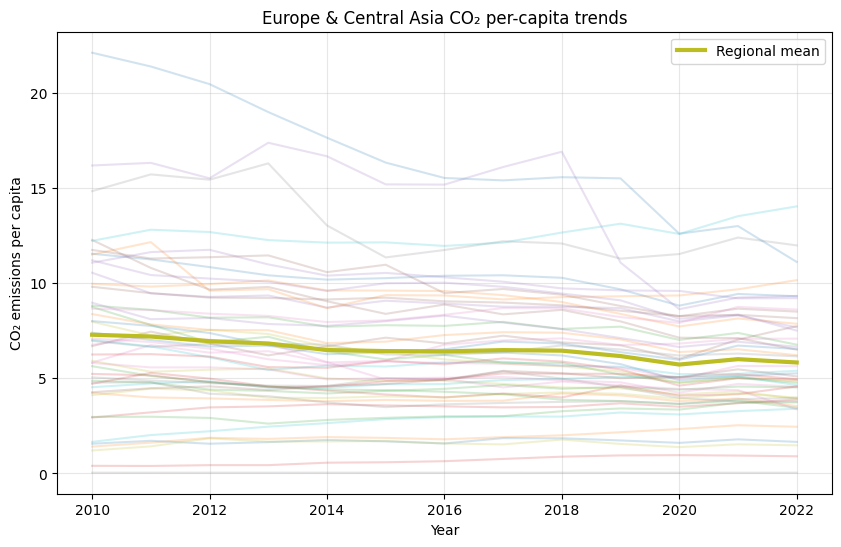

In [21]:
q2_valid = q2_raw.dropna(subset=["CO2_Emissions_Per_Capita"]).copy()

regional_mean = q2_valid.groupby("Year")["CO2_Emissions_Per_Capita"].mean()

plt.figure(figsize=(10,6))
for _, g in q2_valid.groupby("Country_Code"):
    plt.plot(g["Year"], g["CO2_Emissions_Per_Capita"], alpha=0.2)

plt.plot(regional_mean.index, regional_mean.values, linewidth=3, label="Regional mean")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions per capita")
plt.title("Europe & Central Asia CO₂ per-capita trends")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Q2(ii)(b) Visualisation (regional mean with IQR spread)

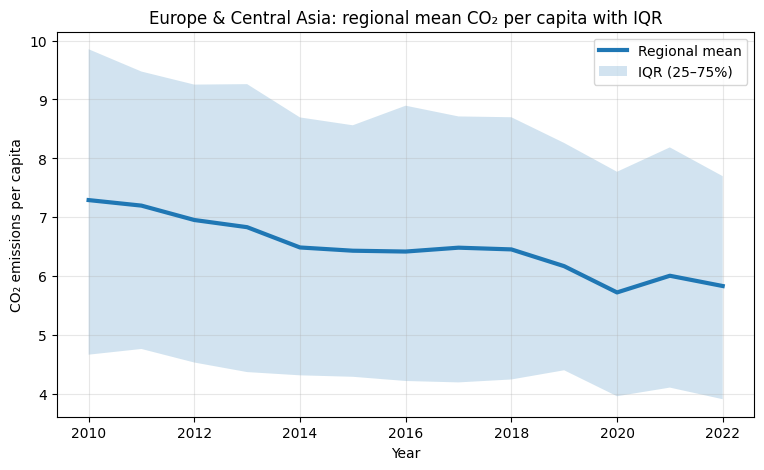

In [22]:
yearly_summary = (
    q2_valid.groupby("Year")["CO2_Emissions_Per_Capita"]
    .agg(
        mean="mean",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

plt.figure(figsize=(9,5))
plt.plot(yearly_summary["Year"], yearly_summary["mean"], linewidth=3, label="Regional mean")
plt.fill_between(yearly_summary["Year"], yearly_summary["q25"], yearly_summary["q75"], alpha=0.2, label="IQR (25–75%)")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions per capita")
plt.title("Europe & Central Asia: regional mean CO₂ per capita with IQR")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Q2(ii)(c) Early vs late descriptive comparison (2010–2012 vs 2020–2022)

In [23]:

early_period = q2_valid[q2_valid["Year"].between(2010, 2012)].copy()
late_period  = q2_valid[q2_valid["Year"].between(2020, 2022)].copy()

early_country_mean = early_period.groupby("Country_Code")["CO2_Emissions_Per_Capita"].mean()
late_country_mean  = late_period.groupby("Country_Code")["CO2_Emissions_Per_Capita"].mean()

def desc_stats(series):
    return pd.Series({
        "n (countries)": int(series.count()),
        "Mean": float(series.mean()),
        "Median": float(series.median()),
        "Standard Deviation": float(series.std()),
        "IQR": float(series.quantile(0.75) - series.quantile(0.25)),
        "Min": float(series.min()),
        "Max": float(series.max())
    })

q2_desc = pd.DataFrame({
    "2010–2012 (early)": desc_stats(early_country_mean),
    "2020–2022 (late)": desc_stats(late_country_mean)
})

display(q2_desc)

,2010–2012 (early),2020–2022 (late)
n (countries),48.000000,48.000000
Mean,7.148681,5.855793
Median,6.831654,5.155907
Standard Deviation,4.167618,2.860408
IQR,4.913280,3.942065
Min,0.041240,0.039429
Max,21.327375,13.386023


## Q2(iii)(a–d) Inferential trend test (Spearman correlation)

In [24]:
regional_yearly = (
    q2_valid.groupby("Year")["CO2_Emissions_Per_Capita"]
    .mean()
    .sort_index()
    .reset_index()
)

display(regional_yearly.head())

from scipy.stats import spearmanr

rho, p_value = spearmanr(
    regional_yearly["Year"],
    regional_yearly["CO2_Emissions_Per_Capita"]
)

print(f"Spearman's rho: {rho:.6f}")
print(f"p-value: {p_value:.10f}")

,Year,CO2_Emissions_Per_Capita
0,2010,7.292720
1,2011,7.198760
2,2012,6.954563
3,2013,6.832716
4,2014,6.488443


Spearman's rho: -0.939560
p-value: 0.0000018782
